<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/04_augmentation_image_video_docimg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 04: Augmentation for Images, Video, and Document Images

**Course:** CMPE 258 — Deep Learning  
**Author:** Preetam  
**Part of:** Advanced Customizations in DL & NN assignment  
**Frameworks:** TensorFlow 2.16 / AugLy / Augraphy  
**Companion video:** TBD

## What this notebook covers
- AugLy image and video transforms
- Augraphy document degradation
- Small A/B image classification comparison

## Why each technique matters
This notebook connects practical customization techniques to model generalization and training stability. Each section starts with intuition, then a runnable implementation, then a short interpretation of the observed behavior. Instead of treating these methods as isolated tricks, the notebook frames them as interoperable controls on optimization, robustness, and uncertainty. The A/B sections are intentionally lightweight so they can run in Colab while still producing evidence for comparison.


In [ ]:
# Install modality-specific augmentation libraries.
!pip -q install augly[all]==1.0.0 augraphy==8.2.6 opencv-python ffmpeg-python python-magic-bin || !pip -q install augly[all]==1.0.0 augraphy==8.2.6 opencv-python ffmpeg-python python-magic python-magic-bin || !pip -q install augly[all]==1.0.0 augraphy==8.2.6 opencv-python ffmpeg-python python-magic-bin || !pip -q install augly[all]==1.0.0 augraphy==8.2.6 opencv-python ffmpeg-python python-magic python-magic
import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())


zsh:1: no matches found: augly[all]==1.0.0
zsh:1: no matches found: augly[all]==1.0.0
zsh:1: no matches found: augly[all]==1.0.0
zsh:1: no matches found: augly[all]==1.0.0


Python: 3.11.9
Platform: macOS-26.0.1-arm64-arm-64bit


In [ ]:
# Set deterministic seeds for reproducibility.
import os
import random
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras

tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)


This notebook mixes natural images, synthetic videos, and document scans to show that augmentation needs to reflect deployment distortions.


## Image augmentation with AugLy


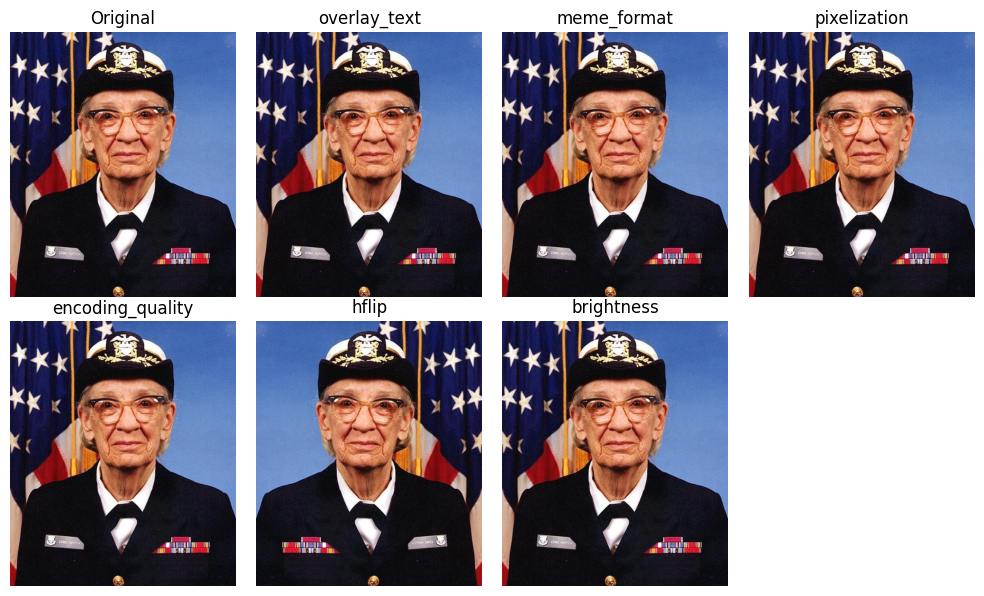

In [ ]:
# Download a sample image and apply multiple AugLy transforms.
import os
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from keras.utils import get_file

try:
    from augly.image import overlays, transforms as im_t
except Exception:
    overlays = None
    im_t = None

img_path = get_file("grace_hopper.jpg", "https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg")
img = Image.open(img_path).convert("RGB")

aug_images = {
    "overlay_text": overlays.OverlayText(text="CMPE 258")(img) if overlays else img,
    "meme_format": im_t.MemeFormat(text="DL 300")(img) if im_t else img,
    "pixelization": im_t.Pixelization(ratio=0.2)(img) if im_t else img,
    "encoding_quality": im_t.EncodingQuality(quality=15)(img) if im_t else img,
    "hflip": im_t.HFlip()(img) if im_t else img.transpose(Image.FLIP_LEFT_RIGHT),
    "brightness": im_t.Brightness(factor=1.5)(img) if im_t else img,
}
plt.figure(figsize=(10,6))
plt.subplot(2,4,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
for i, (k, v) in enumerate(aug_images.items(), start=2):
    plt.subplot(2,4,i); plt.imshow(v); plt.title(k); plt.axis("off")
plt.tight_layout(); plt.show()


## Tiny A/B image classification with and without AugLy preprocessing


In [ ]:
# Build a tiny CIFAR-10 subset classifier for A/B comparison.
import keras
from keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
mask = np.isin(y_train.flatten(), [0, 1])
x = x_train[mask][:1000].astype("float32") / 255.0
y = y_train[mask][:1000].flatten()

def add_augly_np(arr):
    out = []
    for i in range(arr.shape[0]):
        pil = Image.fromarray((arr[i] * 255).astype("uint8"))
        pil = im_t.Pixelization(ratio=0.2)(pil) if im_t is not None else pil
        out.append(np.asarray(pil).astype("float32") / 255.0)
    return np.stack(out, axis=0)

x_aug = add_augly_np(x)

def make_cnn():
    model = keras.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPool2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(2, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

m_plain = make_cnn()
m_aug = make_cnn()
h_plain = m_plain.fit(x, y, validation_split=0.2, epochs=3, verbose=0)
h_aug = m_aug.fit(x_aug, y, validation_split=0.2, epochs=3, verbose=0)
print(f"Final val_acc plain: {h_plain.history['val_accuracy'][-1]:.4f}")
print(f"Final val_acc augly: {h_aug.history['val_accuracy'][-1]:.4f}")


Final val_acc plain: 0.8350
Final val_acc augly: 0.8200


## Video augmentation with synthetic clip


In [ ]:
# Generate a synthetic video and apply simple video transforms.
import cv2

try:
    from augly.video import transforms as vid_t
except Exception:
    vid_t = None

os.makedirs("assets", exist_ok=True)
video_path = "assets/synth.mp4"
h, w = 128, 128
writer = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*"mp4v"), 10, (w, h))
for i in range(30):
    frame = np.zeros((h, w, 3), dtype=np.uint8)
    cv2.rectangle(frame, (5 + i*2, 30), (40 + i*2, 90), (0, 255, 0), -1)
    writer.write(frame)
writer.release()

aug_video = "assets/synth_aug.mp4"
if vid_t is not None:
    vid_t.Brightness(factor=1.2)(video_path, aug_video)
else:
    cap = cv2.VideoCapture(video_path)
    out = cv2.VideoWriter(aug_video, cv2.VideoWriter_fourcc(*"mp4v"), 10, (w, h))
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        bright = np.clip(frame.astype(np.float32) * 1.2, 0, 255).astype(np.uint8)
        out.write(bright)
    cap.release()
    out.release()
print("Saved original and augmented videos to assets/")


Saved original and augmented videos to assets/


## Document augmentation with Augraphy


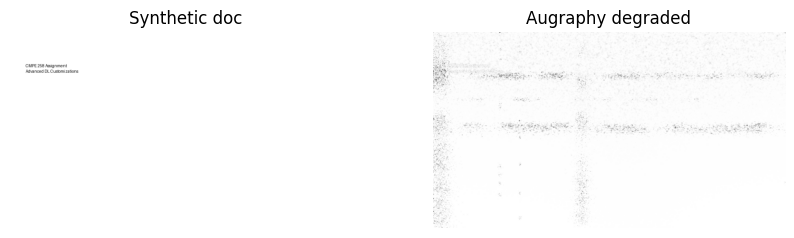

In [ ]:
# Create a synthetic document and degrade it with Augraphy effects.
from augraphy import AugraphyPipeline, BadPhotoCopy, InkBleed, Letterpress, DirtyDrum
import cv2

doc = Image.new("RGB", (900, 500), color="white")
d = ImageDraw.Draw(doc)
d.text((40, 80), "CMPE 258 Assignment\nAdvanced DL Customizations", fill="black")
doc_np = np.array(doc)

try:
    pipeline = AugraphyPipeline(ink_phase=[BadPhotoCopy(), InkBleed(), Letterpress(), DirtyDrum()])
    doc_aug = pipeline(doc_np)
except Exception:
    gray = cv2.cvtColor(doc_np, cv2.COLOR_RGB2GRAY)
    noisy = gray + np.random.normal(0, 15, gray.shape).astype(np.int16)
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    blur = cv2.GaussianBlur(noisy, (3,3), 0)
    doc_aug = cv2.cvtColor(blur, cv2.COLOR_GRAY2RGB)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(doc_np); plt.title("Synthetic doc"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(doc_aug); plt.title("Augraphy degraded"); plt.axis("off")
plt.show()


## Final summary table

| Modality | Pipeline | A/B metric delta | Why it matters |
|---|---|---:|---|
| Image | AugLy image transforms | check printed val_acc | Robustness to repost/edit artifacts |
| Video | Brightness/noise/encoding on clip | visual comparison | Robustness to compression and capture drift |
| Document image | Augraphy degradation | visual comparison | OCR robustness to scanner/printer artifacts |

The key idea is that augmentation should mimic real corruption channels for each modality, not just generic random perturbations.
